# Step 2: Load the datasets

This notebook downloads the Kaggle "Fashion Product Images (Small)" dataset and does a first look at both it and your board images.

In [ ]:
import kagglehub

# This downloads the dataset (once) and caches it locally.
# It returns the local folder path where the files live.
path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-small")

print("Path to dataset files:", path)

## Look inside the downloaded folder

Before writing code that assumes a file structure, let's actually check it — dataset layouts vary (sometimes there's a nested subfolder, sometimes not).

In [2]:
from pathlib import Path

dataset_root = Path(path)

# List top-level contents
print("Top-level contents:")
for p in sorted(dataset_root.iterdir()):
    print(" ", p.name)

# List one level deeper, in case of a nested folder
print("\nOne level deeper:")
for sub in sorted(dataset_root.iterdir()):
    if sub.is_dir():
        for p in sorted(sub.iterdir())[:10]:
            print(" ", p.relative_to(dataset_root))

Top-level contents:
  images
  myntradataset
  styles.csv

One level deeper:


  images/10000.jpg
  images/10001.jpg
  images/10002.jpg
  images/10003.jpg
  images/10004.jpg
  images/10005.jpg
  images/10006.jpg
  images/10007.jpg
  images/10008.jpg
  images/10009.jpg
  myntradataset/images
  myntradataset/styles.csv


**Findings:** the dataset has `images/` (the actual .jpg files) and `styles.csv` (metadata) at the top level, plus a duplicate `myntradataset/` subfolder we'll ignore. Let's load the metadata into a **pandas DataFrame** — basically a spreadsheet/table object in Python, where each row is one clothing item and each column is an attribute (category, color, usage, etc.). It lets us filter, group, and join this data with code instead of clicking around a spreadsheet.

In [3]:
import pandas as pd

images_dir = dataset_root / "images"
styles_csv = dataset_root / "styles.csv"

# Some rows in this CSV have malformed extra commas (product names containing commas) --
# on_bad_lines="skip" drops the handful of broken rows instead of erroring out.
df = pd.read_csv(styles_csv, on_bad_lines="skip")

print("Shape (rows, columns):", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape (rows, columns): (44424, 10)

Columns: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


## The `usage` column — our future classifier's target label

This is the column Step 8 will train a classifier to predict. Let's check the class balance now, since it affects how we'll need to handle training later.

In [4]:
df["usage"].value_counts(dropna=False)

usage
Casual          34406
Sports           4025
Ethnic           3208
Formal           2345
NaN               317
Smart Casual       67
Party              29
Travel             26
Home                1
Name: count, dtype: int64

## Load your board images\n\nNow let's check the images you saved into `data/board_images/`.


Found 10 board images


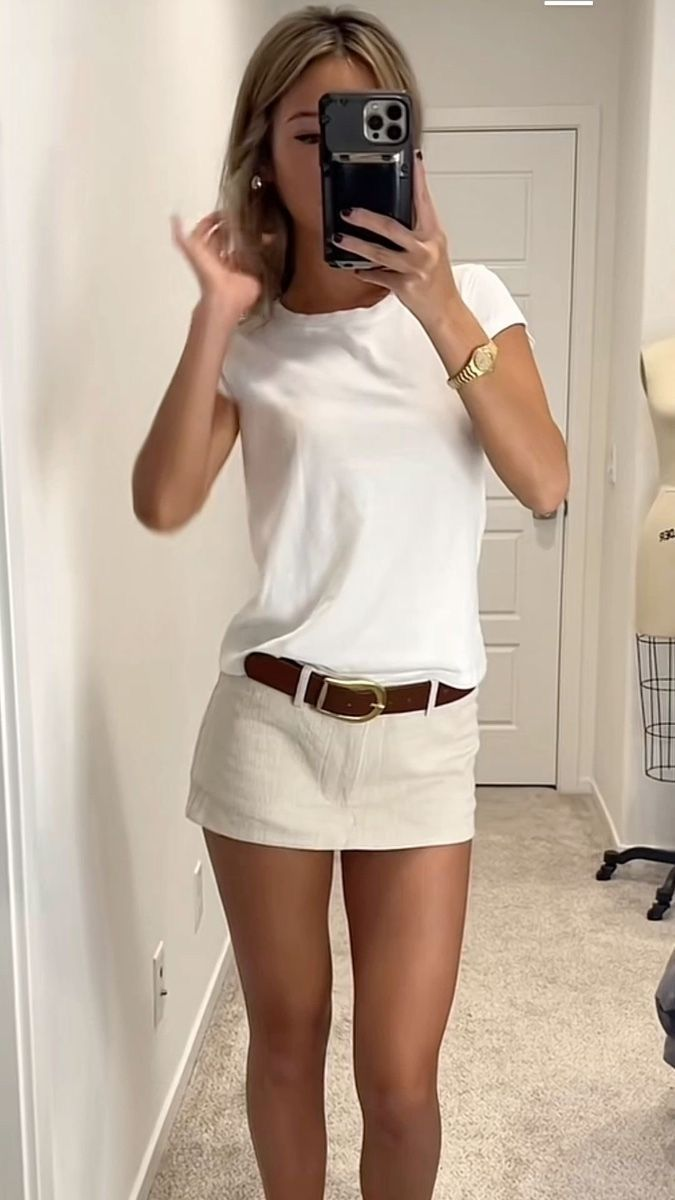

In [5]:
from PIL import Image

board_dir = Path("../data/board_images")
board_image_paths = sorted([
    p for p in board_dir.iterdir()
    if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"}
])

print(f"Found {len(board_image_paths)} board images")

if not board_image_paths:
    print("No images found yet -- add some to data/board_images/ and re-run this cell.")
else:
    # Show the first one as a sanity check
    display(Image.open(board_image_paths[0]))